SHAP computation complete | Shape: (1409, 32)


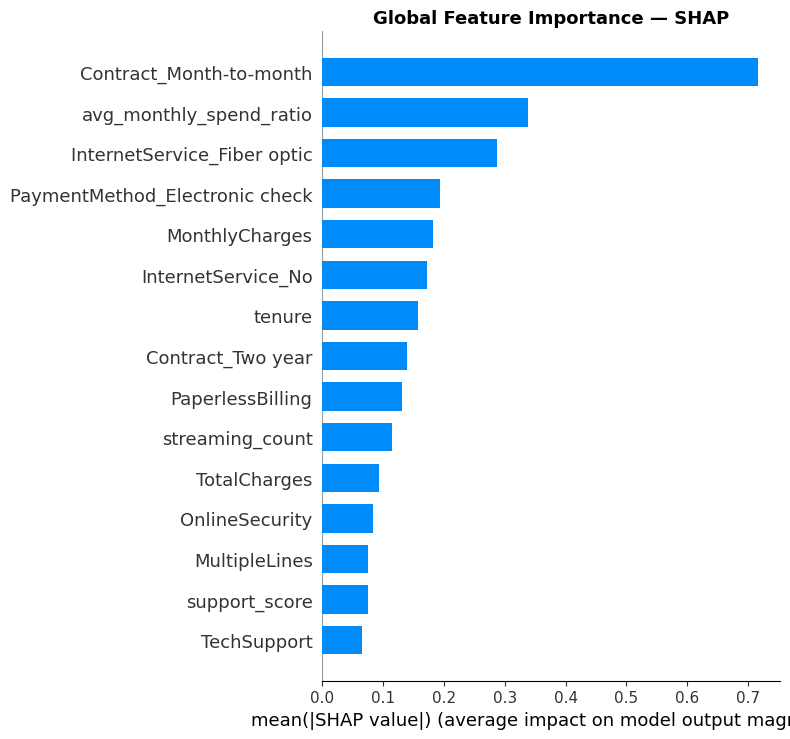

Global importance chart saved.


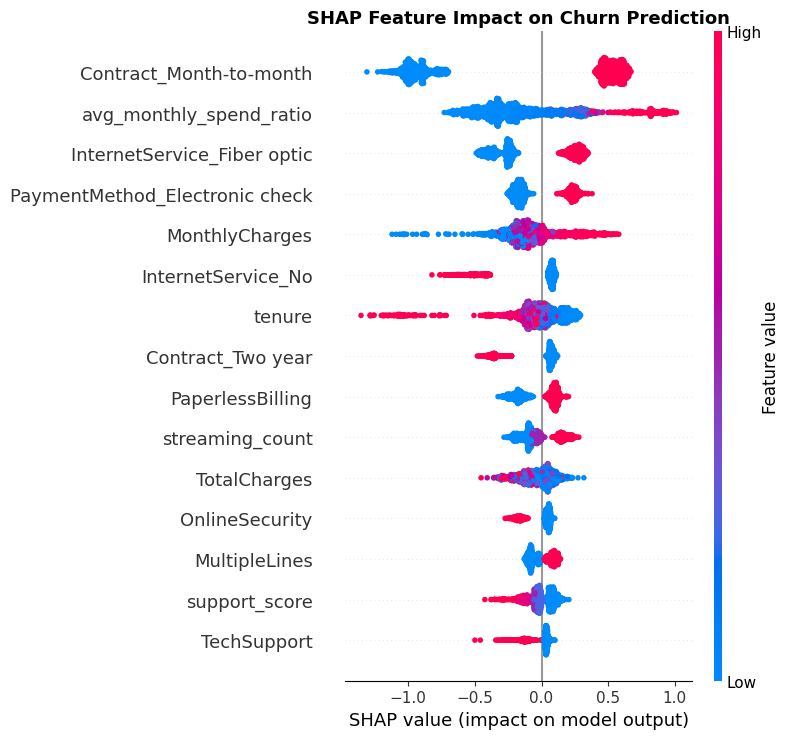

Beeswarm chart saved.

Highest risk customer churn probability: 96.7%


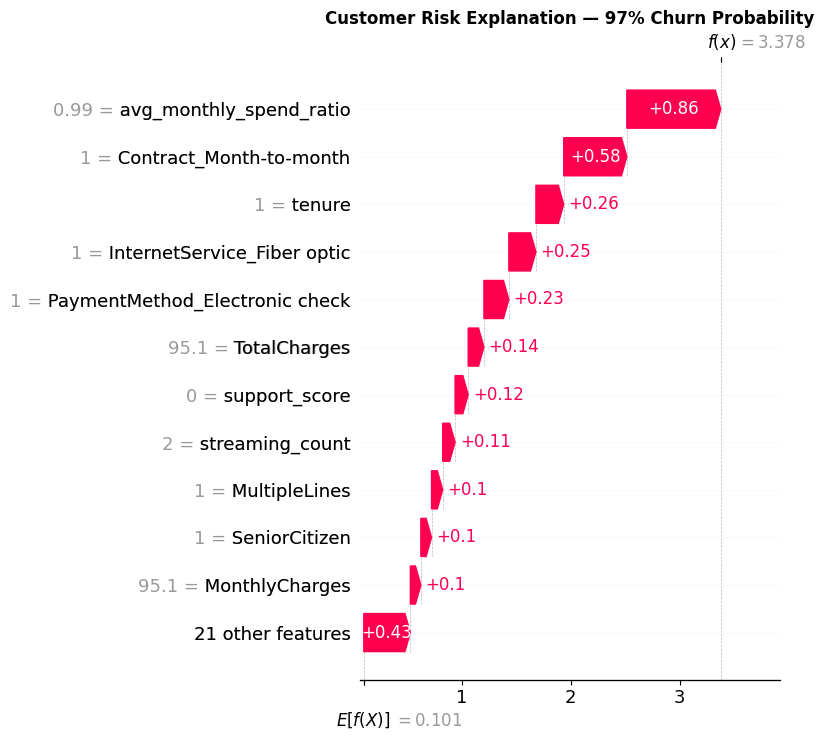

Waterfall chart saved.

Top 5 Churn Drivers (by mean absolute SHAP value):
---------------------------------------------
  1. Contract_Month-to-month             0.7167
  2. avg_monthly_spend_ratio             0.3382
  3. InternetService_Fiber optic         0.2866
  4. PaymentMethod_Electronic check      0.1931
  5. MonthlyCharges                      0.1822
---------------------------------------------

Notebook 4 complete.
  outputs/06_shap_global.png
  outputs/07_shap_beeswarm.png
  outputs/08_shap_waterfall.png
  outputs/shap_values.csv


In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

# Load model and data
model = joblib.load('../outputs/model.pkl')
df = pd.read_csv('../data/processed/features.csv')

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
print(f"SHAP computation complete | Shape: {shap_values.shape}")

# --- Plot 1: Global Feature Importance ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=15, show=False)
plt.title('Global Feature Importance — SHAP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/06_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()
print("Global importance chart saved.")

# --- Plot 2: Beeswarm ---
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/07_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm chart saved.")

# --- Plot 3: Single Customer Waterfall ---
probs = model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(probs)
prob = probs[high_risk_idx]
print(f"\nHighest risk customer churn probability: {prob*100:.1f}%")

shap_exp = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=X_test.columns.tolist()
)
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'Customer Risk Explanation — {prob*100:.0f}% Churn Probability', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/08_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall chart saved.")

# --- Top 5 Global Churn Drivers ---
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("\nTop 5 Churn Drivers (by mean absolute SHAP value):")
print("-" * 45)
for i, (feat, val) in enumerate(mean_shap.head(5).items()):
    print(f"  {i+1}. {feat:<35} {val:.4f}")
print("-" * 45)

# --- Save SHAP values ---
shap_df = pd.DataFrame(shap_values, columns=X_test.columns)
shap_df['churn_probability'] = probs
shap_df.to_csv('../outputs/shap_values.csv', index=False)

print("\nNotebook 4 complete.")
print("  outputs/06_shap_global.png")
print("  outputs/07_shap_beeswarm.png")
print("  outputs/08_shap_waterfall.png")
print("  outputs/shap_values.csv")